<a href="https://colab.research.google.com/github/cristian0527/MATH-383/blob/main/Load_Classrooms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Problem (4): Kindergarden Classrooms Network Data

https://github.com/cristian0527/MATH-383/blob/main/Load_Classrooms.ipynb

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from networkx.readwrite import json_graph
import json


In [18]:
networks = []
for i in [1,2,3,4,5,6]:

    with open(f'./classroom_{i}.json') as f:
        data = json.load(f)
        networks.append(json_graph.adjacency_graph(data))


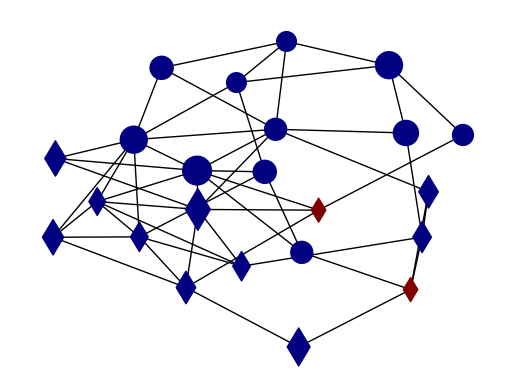

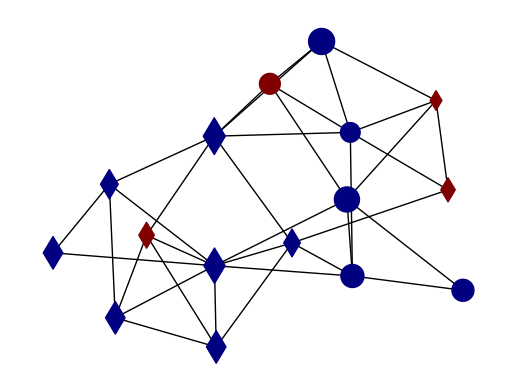

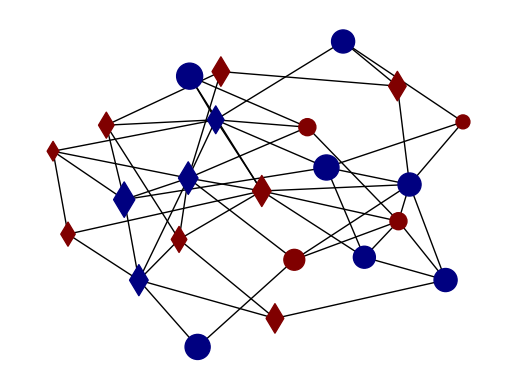

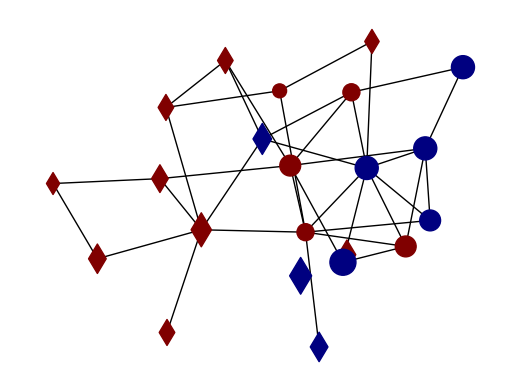

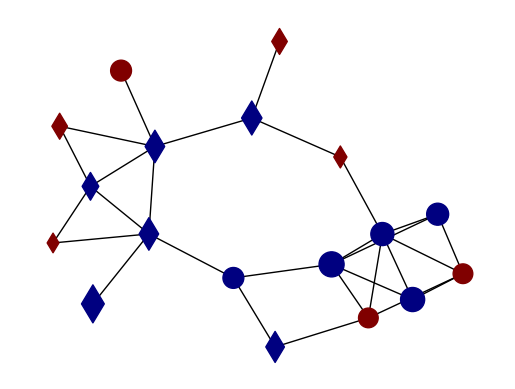

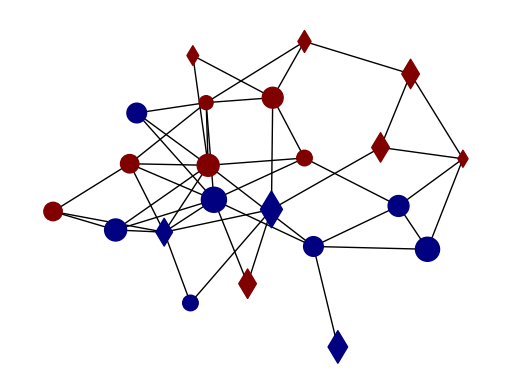

In [19]:
node_shapes = [[] for x in range(len(networks))]
shape_dict = {'MALE': 'o', 'FEMALE':'s'}

for i in range(len(networks)):
    kk0 = nx.kamada_kawai_layout(networks[i])

    nx.draw_networkx_nodes(networks[i],pos=kk0,node_shape = 'd',
                           nodelist = [x for x in networks[i].nodes() if networks[i].nodes[x]['Gender']=='MALE'],
                           node_color=[networks[i].nodes[x]['Risk'] for x in networks[i].nodes() if networks[i].nodes[x]['Gender']=='MALE'],cmap='jet',
                          node_size = [networks[i].nodes[x]['CELF']*25 for x in networks[i].nodes() if networks[i].nodes[x]['Gender']=='MALE'])

    nx.draw_networkx_nodes(networks[i],pos=kk0,node_shape = 'o',
                           nodelist = [x for x in networks[i].nodes() if networks[i].nodes[x]['Gender']=='FEMALE'],
                           node_color=[networks[i].nodes[x]['Risk'] for x in networks[i].nodes() if networks[i].nodes[x]['Gender']=='FEMALE'],
                           cmap='jet',node_size = [networks[i].nodes[x]['CELF']*25 for x in networks[i].nodes() if networks[i].nodes[x]['Gender']=='FEMALE'])

    nx.draw_networkx_edges(networks[i],pos = kk0)

    plt.axis('off')
    plt.show()



#### (A) Classrooms & 100 Erdos–Renyi networks:
After running 100 Erdos-Renyi networks on classrooms 1, 2, 3, 4, 5, and 6, All except 3 & 4 show higher transitivity than what would be expected from random graphs with matching parameters. The transitivity values fell to the right of their respective Erdos-Renyi distributions, which provides some strong evidence that these networks have genuine social structure that cannot be explained by random chance alone.

Classroom 3 & 4 transitivity values fell in the center of the Erdo-Renyi distribution meaning that a random graph with the same number of nodes and edge density would be likely be able to produce a graph similar to the original classroom.

In [24]:
def compare_to_er(G, num_sims=100):
    """compare network G to Erdős-Rényi random graphs"""
    n = G.order()  # number of nodes
    p = nx.density(G)  # edge density

    # Real network stats
    real_transitivity = nx.transitivity(G)

    # 100 ER graphs and compute transitivity
    er_transitivities = []
    for i in range(num_sims):
        er = nx.erdos_renyi_graph(n, p)
        er_transitivities.append(nx.transitivity(er))

    return real_transitivity, er_transitivities

Classroom 1
Nodes: 23, Edges: 51, Density: 0.20158
Real transitivity: 0.28708
ER mean transitivity: 0.19261
Difference: 0.09448


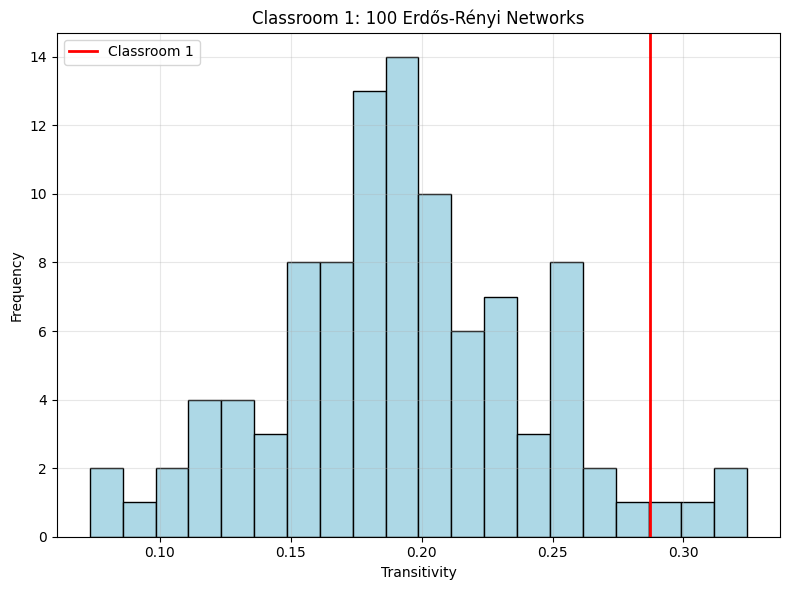

Classroom 2
Nodes: 16, Edges: 35, Density: 0.29167
Real transitivity: 0.35556
ER mean transitivity: 0.27651
Difference: 0.07905


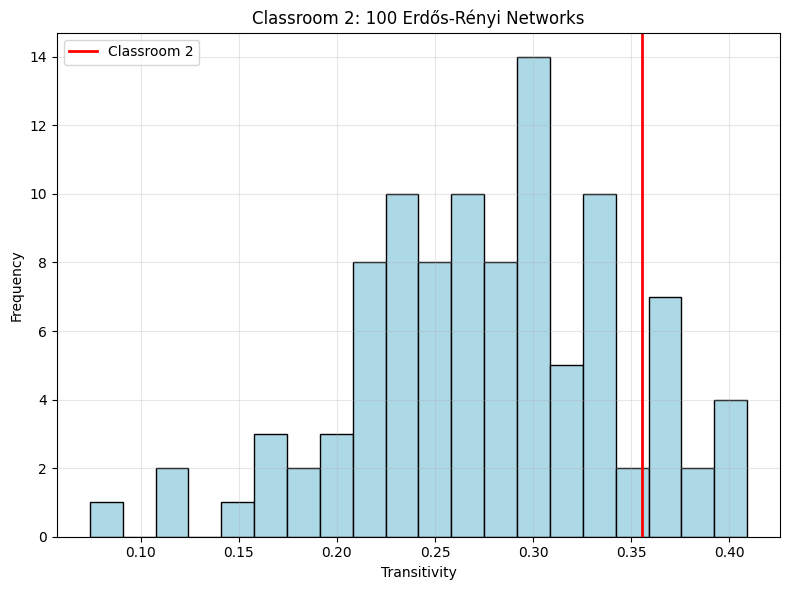

Classroom 3
Nodes: 23, Edges: 53, Density: 0.20949
Real transitivity: 0.20779
ER mean transitivity: 0.21276
Difference: -0.00497


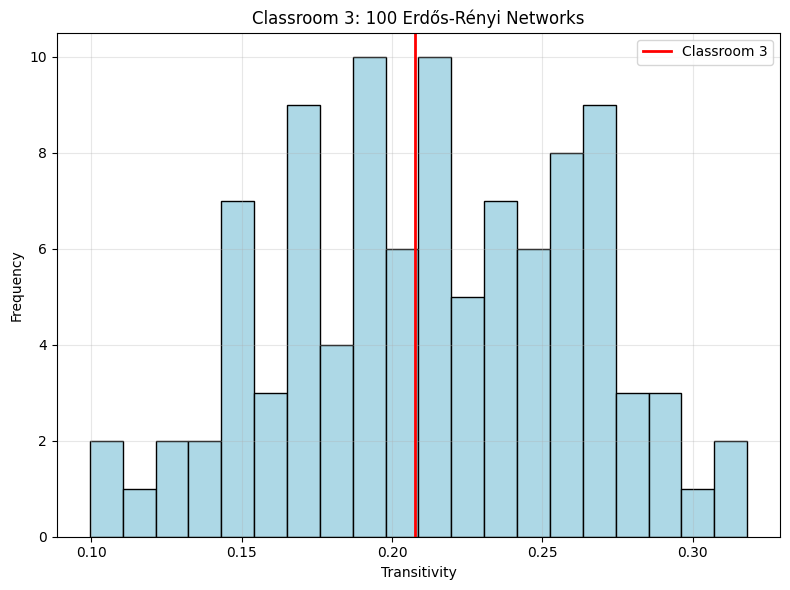

Classroom 4
Nodes: 22, Edges: 36, Density: 0.15584
Real transitivity: 0.13953
ER mean transitivity: 0.14508
Difference: -0.00555


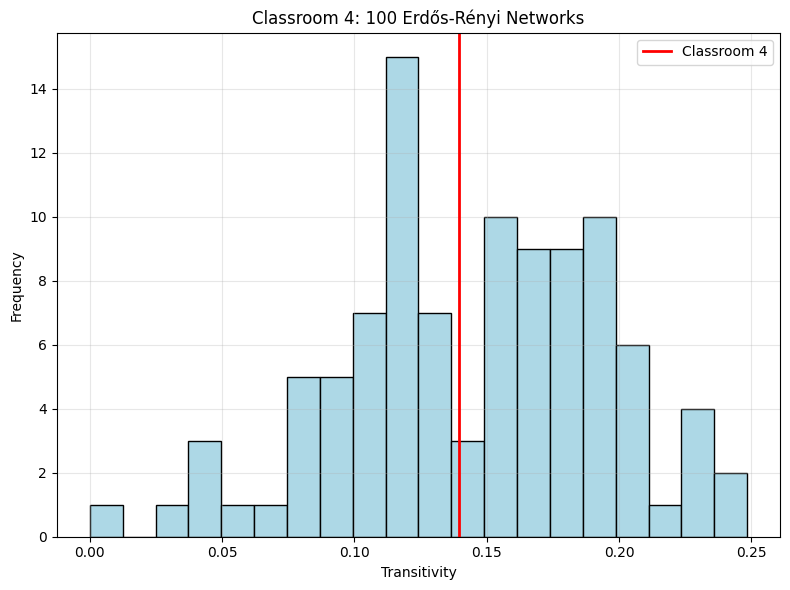

Classroom 5
Nodes: 18, Edges: 28, Density: 0.18301
Real transitivity: 0.34177
ER mean transitivity: 0.18745
Difference: 0.15432


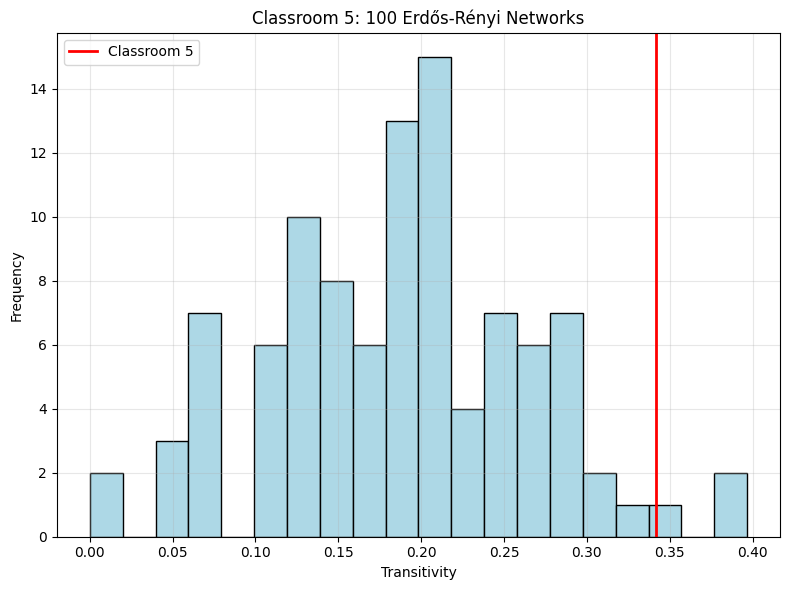

Classroom 6
Nodes: 22, Edges: 45, Density: 0.19481
Real transitivity: 0.25424
ER mean transitivity: 0.18992
Difference: 0.06432


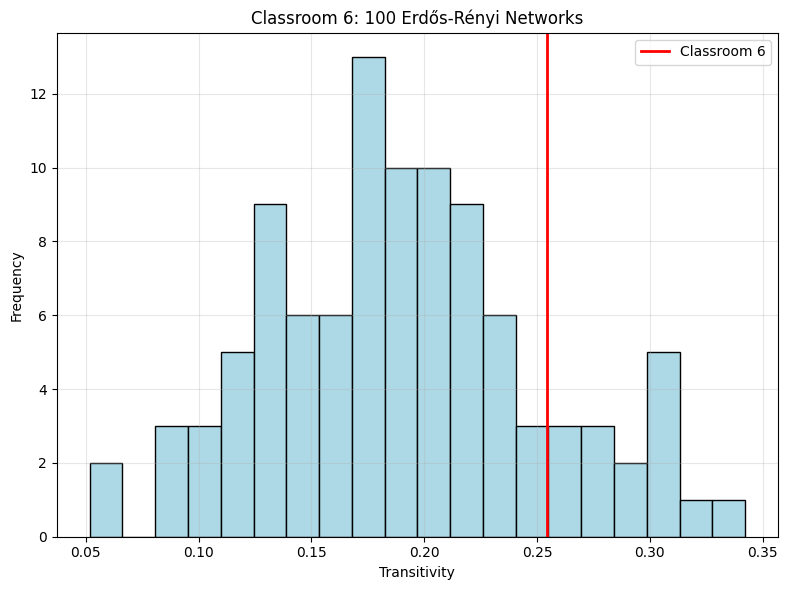

In [23]:
for idx, classroom_id in enumerate([1,2,3,4,5,6]):
    G = networks[idx]

    print(f"Classroom {classroom_id}")
    print(f"Nodes: {G.order()}, Edges: {G.size()}, Density: {nx.density(G):.5f}")

    real_trans, er_trans = compare_to_er(G)

    print(f"Real transitivity: {real_trans:.5f}")
    print(f"ER mean transitivity: {np.mean(er_trans):.5f}")
    print(f"Difference: {real_trans - np.mean(er_trans):.5f}")

    # histogram
    plt.figure(figsize=(8, 6))
    plt.hist(er_trans, bins=20, color='lightblue', edgecolor='black')
    plt.axvline(real_trans, color='red', linewidth=2, label=f'Classroom {classroom_id}')
    plt.xlabel('Transitivity')
    plt.ylabel('Frequency')
    plt.title(f'Classroom {classroom_id}: 100 Erdős-Rényi Networks')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### (B): Arrival of a new student

Method for deciding who that student might choose to
connect to in the classroom: Students befriend someone based on how similar they are to each other. For the 100 simulations, this new student was given random gender and risk attributes. For risk, I was kind of confused what this meant, but I thought about it as metric to identify a student's risk socially (e.g., being shy/timid). So I just matched with probabilities how they would connect given a similarity score.

The degree distribution matches pretty well. This new random student develop a similar average number of connections as existing students. Though, the clustering coefficient reveals a problem of existing students showing substantial clustering, but the new random student, in comparison, have way lower clustering (with a huge spike at 0.0), meaning their friends rarely know each other.

I think that although to some sense the model I built did a good job with identifying degree centrality, it did not do a pretty good job of capturing clusterings (students befriending each other and becoming close). Which is disappointing to see since I would think that kindergardeners are pretty close to each other. So because of that, I would say I am not too confident in my model to reproduce the dynamics that were formed in classroom 1 network originally.

In [37]:
def add_student_similar_traits(G):
    """new student connects to similar students"""
    # randomly give new student attributes
    new_node = max(G.nodes()) + 1
    new_gender = np.random.choice(['MALE', 'FEMALE'])
    new_risk = np.random.uniform(
        min(G.nodes[n]['Risk'] for n in G.nodes()),
        max(G.nodes[n]['Risk'] for n in G.nodes())
    )

    G.add_node(new_node, Gender=new_gender, Risk=new_risk)

    # similarity scores
    similarities = {}
    for node in G.nodes():
        if node == new_node:
            continue
        sim = 0
        # match gender
        if G.nodes[node]['Gender'] == new_gender:
            sim += 1
        # risk similarity
        risk_diff = abs(G.nodes[node]['Risk'] - new_risk)
        sim += 1 / (1 + risk_diff)  # closer in risk would have higher similarity

        similarities[node] = sim

    # probabilities
    total = sum(similarities.values())
    probs = [similarities[n]/total for n in similarities.keys()]

    # sample number of friends
    num_friends = np.random.choice([d for n, d in G.degree()])

    # choose based on similarity
    chosen = np.random.choice(list(similarities.keys()),
                             size=min(num_friends, len(similarities)),
                             replace=False, p=probs)

    for node in chosen:
        G.add_edge(new_node, node)

    return G, new_node

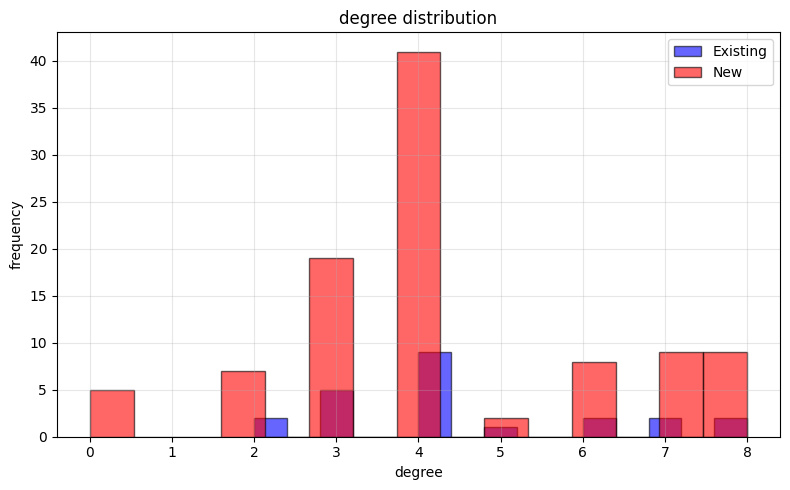

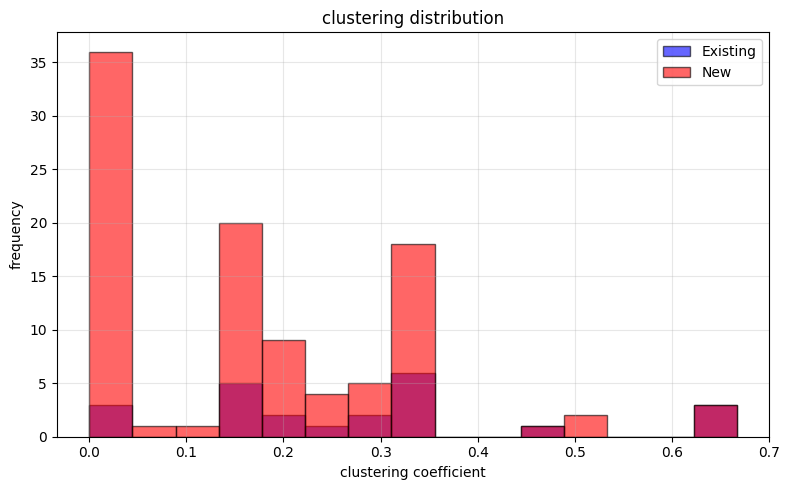

In [36]:
G_original = networks[0].copy()

# 100 simulations & record their stats
new_student_degrees = []
new_student_clustering = []

for i in range(100):
    G_with_new_student = G_original.copy()

    # add new student
    G_with_new_student, new_student_id = add_student_similar_traits(G_with_new_student)

    # new student's metadata
    new_student_degrees.append(G_with_new_student.degree(new_student_id))
    new_student_clustering.append(nx.clustering(G_with_new_student, new_student_id))

# compare to existing students in the original network
existing_degrees = [d for n, d in G_original.degree()]
existing_clustering = [nx.clustering(G_original, n) for n in G_original.nodes()]


# degree plot
plt.figure(figsize=(8, 5))
plt.hist(existing_degrees, bins=15, alpha=0.6, color='blue', label='Existing', edgecolor='black')
plt.hist(new_student_degrees, bins=15, alpha=0.6, color='red', label='New', edgecolor='black')
plt.xlabel('degree')
plt.ylabel('frequency')
plt.title('degree distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n')

# clustering plot
plt.figure(figsize=(8, 5))
plt.hist(existing_clustering, bins=15, alpha=0.6, color='blue', label='Existing', edgecolor='black')
plt.hist(new_student_clustering, bins=15, alpha=0.6, color='red', label='New', edgecolor='black')
plt.xlabel('clustering coefficient')
plt.ylabel('frequency')
plt.title('clustering distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()